<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/02_informative_slope_prior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 2 — Informative slope prior

Keep the same Gaussian regression but deliberately make the prior on the daily deprivation effect much tighter. This makes prior influence visible rather than merely discussing it abstractly.

## Setup

This course pins PyMC, modular ArviZ, and Bambi for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1" \
    "bambi==0.21.0" \n    "jinja2>=3.1.5"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\admin_local\dev\learning\BayesianShortCourse\.venv\Scripts\python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '\\n': Expected package name at the start of dependency specifier
    \n
    ^
Hint: It looks like a path. File '\n' does not exist.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bambi as bmb
import pymc as pm
import arviz_base as azb
import arviz_stats as azs
import arviz_plots as azp

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

# Predictive-band colours: one hue per stage, light (90%) -> darker (50%) -> line
PRIOR_90, PRIOR_50, PRIOR_LINE = "#cde2fb", "#86b6ef", "#2a78d6"  # blue
POST_90, POST_50, POST_LINE = "#fbdccd", "#f5a888", "#eb6834"     # orange
OBS = "#52514e"                                                   # observed data

print("PyMC:", pm.__version__)
print("Bambi:", bmb.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
Bambi: 0.21.0
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every Bambi model in this sequence uses `center_predictors=False`. The `Intercept` prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


# 2.1 A skeptical slope prior

What does the model imply if we strongly expect the daily effect of sleep deprivation to be near zero?

We keep the literature priors from notebook 01 for the intercept and $\sigma$ and change **only** our belief about the slope. We are now convinced that sleep deprivation does almost nothing, about **0.01 ms per day**:

$$\beta \sim \mathcal{N}(0.01,\ 0.01)\ \text{ms/day}$$

With 95% probability the daily effect is between −0.01 and +0.03 ms, so after 7 nights at most about ±0.2 ms. For comparison, notebook 01's prior was N(10, 10) and its posterior about 11.6 ms/day.

### Check 1: prior predictive

In [4]:
priors_skeptical = {
    "Intercept": bmb.Prior("Normal", mu=250, sigma=30),
    "Days": bmb.Prior("Normal", mu=0.01, sigma=0.01),
    "sigma": bmb.Prior("HalfNormal", sigma=50),
}
model = bmb.Model("Reaction ~ Days", sleep, priors=priors_skeptical, center_predictors=False)
model.build()

with model.backend.model:
    prior = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)
model

Sampling: [Days, Intercept, Reaction, sigma]


       Formula: Reaction ~ Days
        Family: gaussian
          Link: mu = identity
  Observations: 144
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 250.0, sigma: 30.0)
            Days ~ Normal(mu: 0.01, sigma: 0.01)
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 50.0)

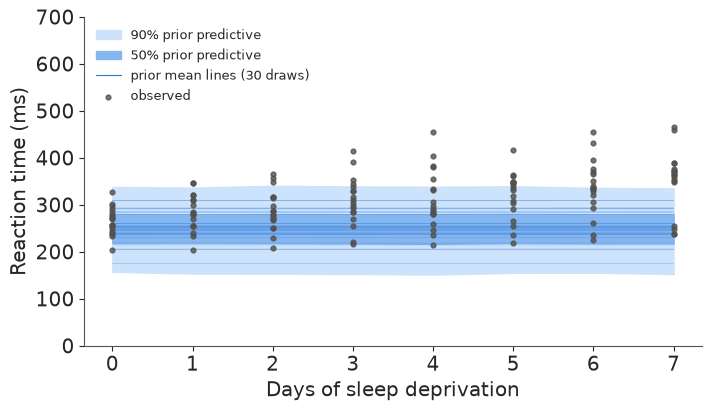

Prior 7-day change, 95% range : -0.07 to 0.20 ms
P(7-day change > 1 ms)        = 0.000
Observed day-7 minus day-0 mean: 85.5 ms
P(predicted RT < 100 ms)      = 0.014


In [5]:
alpha = prior["prior"]["Intercept"].values.ravel()
beta = prior["prior"]["Days"].values.ravel()
y_prior = prior["prior_predictive"]["Reaction"].values.reshape(-1, len(sleep))

days = np.arange(8)
fig, ax = plt.subplots(figsize=(7, 4))
band = {q: np.array([np.percentile(y_prior[:, sleep["Days"] == d], [50 - q / 2, 50 + q / 2]) for d in days])
        for q in (90, 50)}
ax.fill_between(days, *band[90].T, color=PRIOR_90, label="90% prior predictive")
ax.fill_between(days, *band[50].T, color=PRIOR_50, label="50% prior predictive")
for a, b in zip(alpha[:30], beta[:30]):
    ax.plot(days, a + b * days, color=PRIOR_LINE, lw=0.5, alpha=0.35)
ax.plot([], [], color=PRIOR_LINE, lw=0.8, label="prior mean lines (30 draws)")
ax.scatter(sleep["Days"], sleep["Reaction"], s=12, color=OBS, alpha=0.8, label="observed", zorder=3)
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)", ylim=(0, 700))
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.show()

print(f"Prior 7-day change, 95% range : {np.percentile(7 * beta, 2.5):.2f} to {np.percentile(7 * beta, 97.5):.2f} ms")
print(f"P(7-day change > 1 ms)        = {(7 * beta > 1).mean():.3f}")
print(f"Observed day-7 minus day-0 mean: "
      f"{sleep.loc[sleep.Days == 7, 'Reaction'].mean() - sleep.loc[sleep.Days == 0, 'Reaction'].mean():.1f} ms")
print(f"P(predicted RT < 100 ms)      = {(y_prior < 100).mean():.3f}")

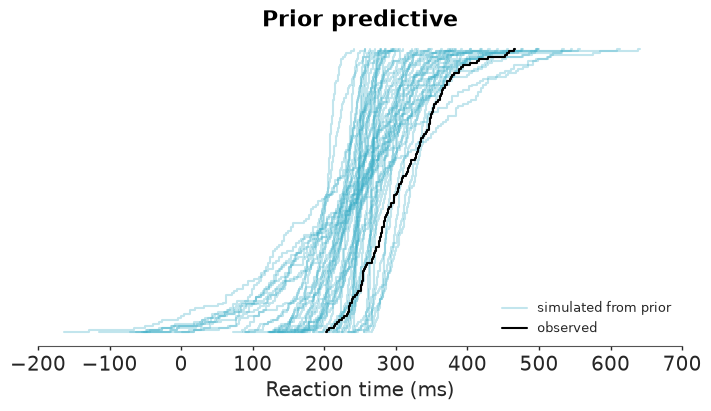

In [6]:
azp.plot_ppc_dist(prior, group="prior_predictive", var_names=["Reaction"], kind="ecdf",
                  visuals={"observed_dist": True}, figure_kwargs={"figsize": (7, 4)})

ax = plt.gcf().axes[0]
ax.set(xlabel="Reaction time (ms)", title="Prior predictive", xlim=(-200, 700))
ax.legend([ax.lines[0], ax.lines[-1]], ["simulated from prior", "observed"], frameon=False, fontsize=9, loc="lower right")
plt.show()

**Verdict: the prior is internally sensible but clashes with the data.**

- Every prior line is **flat**. The prior allows a 7-day change of only −0.07 to +0.20 ms (95% range), while the observed day-7 mean is **85.5 ms** slower than day 0. That is about 400 prior SDs away.
- Reaction times themselves look plausible, as in notebook 01: around 250 ms, with 1.4% below 100 ms from the unbounded Gaussian.
- With the data overlaid, many points from day 3 onwards lie above the prior band, and the observed ECDF sits on the slow edge of the simulated ones.

A prior this confident has two ways out. Either the data pull the slope away from 0.01 anyway, or the model keeps the flat line and explains the slowing as extra noise ($\sigma$). Section 2.2 shows which happens.

# 2.2 Data versus prior

How far does the posterior move away from a tight slope prior centered at zero?

We now fit the skeptical model to the data. Before reading any estimate we run the same two checks as in notebook 01: **sampler diagnostics** (can we trust the numbers?) and a **posterior predictive check** (does the fitted model reproduce the data?).

### Check 2: sampler diagnostics

What to look for: 0 divergences, $\hat R \le 1.01$, ESS in the hundreds or more, **trace plots** that look like stationary noise (no trend, all chains overlapping), and rank plots that stay inside their envelope.

In [7]:
idata = model.fit(draws=2000, tune=2000, chains=4, random_seed=RANDOM_SEED)

print("Divergences:", int(idata["sample_stats"]["diverging"].sum()))
azs.summary(idata, var_names=["Intercept", "Days", "sigma"], ci_prob=0.9, ci_kind="hdi")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, Days]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 19 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,306.53,4.7,300,310,13513,6498,1.00,0.041,0.055
Days,0.0102,0.0099,-0.0057,0.027,11792,6710,1.00,9.1e-05,0.00011
sigma,57.31,3.43,52,63,13186,5857,1.00,0.03,0.04


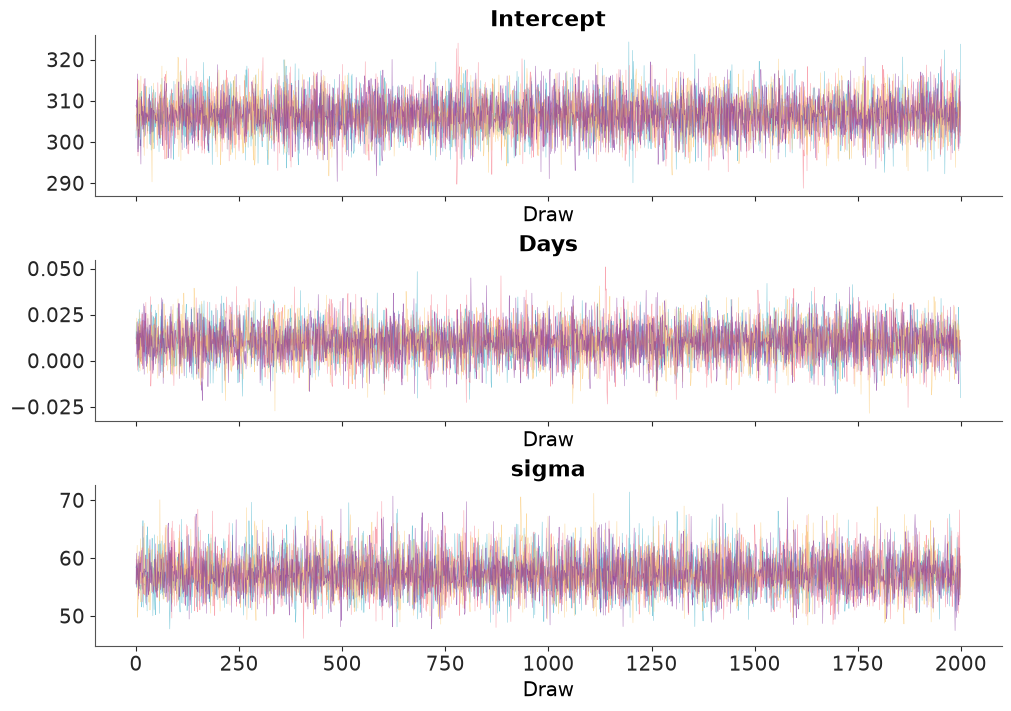

In [8]:
# one row per parameter, thin semi-transparent lines so all four chains stay visible
azp.plot_trace(idata, var_names=["Intercept", "Days", "sigma"], col_wrap=1,
               visuals={"trace": {"linewidth": 0.4, "alpha": 0.6}}, figure_kwargs={"figsize": (10, 7)});

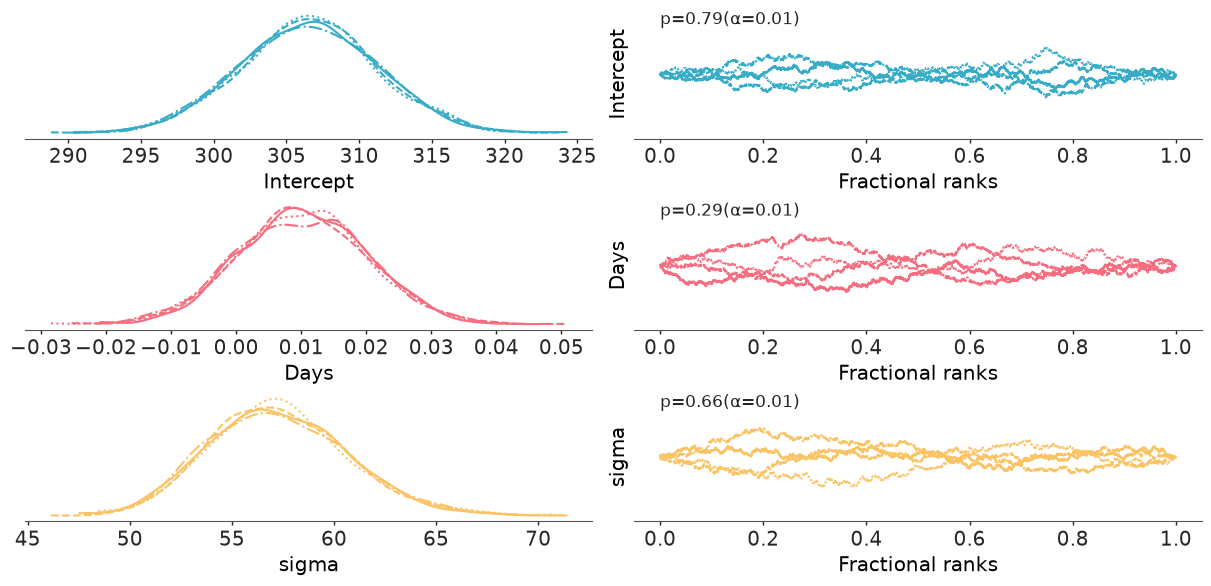

In [9]:
azp.plot_rank_dist(idata, var_names=["Intercept", "Days", "sigma"]);

**Verdict: the sampler passes, better than in notebook 01.** There are 0 divergences, $\hat R = 1.00$, ESS above 5800, and the trace plots are stationary noise with all chains overlapping, and all rank tests pass comfortably (p = 0.29–0.79). With the slope essentially fixed by the prior, the intercept–slope correlation that slowed notebook 01's chains is gone.

So the numbers are computed correctly. Whether they are *right* is a different question.

**Prior–data conflict.** Power-scaling (as in 1.4) measures how much each posterior moves when the prior or the likelihood is made slightly stronger or weaker. If **both** move it, prior and data pull in different directions, and ArviZ labels this a prior–data conflict.

In [10]:
model.compute_log_likelihood(idata)  # Bambi adds these to idata in place
model.compute_log_prior(idata)

azs.psense_summary(idata, var_names=["Intercept", "Days", "sigma"])

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
Intercept,0.043,0.111,✓
Days,0.078,0.006,potential strong prior / weak likelihood
sigma,0.010,0.106,✓


**Skeptical vs. literature prior.** The same data fitted with notebook 01's prior N(10, 10) on the slope:

In [11]:
priors_literature = {**priors_skeptical, "Days": bmb.Prior("Normal", mu=10, sigma=10)}
model_lit = bmb.Model("Reaction ~ Days", sleep, priors=priors_literature, center_predictors=False)
idata_lit = model_lit.fit(draws=2000, tune=2000, chains=4, random_seed=RANDOM_SEED, progressbar=False)
print("Divergences (literature prior):", int(idata_lit["sample_stats"]["diverging"].sum()))

fits = {"Skeptical N(0.01, 0.01)": idata, "Literature N(10, 10)": idata_lit}
pd.concat(
    {label: azs.summary(fit, var_names=["Intercept", "Days", "sigma"], kind="stats",
                        ci_prob=0.9, ci_kind="hdi", round_to=2)
     for label, fit in fits.items()}
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, Days]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 18 seconds.


Divergences (literature prior): 0


mean    sd  hdi90_lb  hdi90_ub
Skeptical N(0.01, 0.01) Intercept  306.53  4.73    298.60    314.32
                        Days         0.01  0.01     -0.01      0.03
                        sigma       57.31  3.43     51.81     62.83
Literature N(10, 10)    Intercept  266.97  7.46    254.87    279.37
                        Days        11.61  1.80      8.55     14.40
                        sigma       51.10  2.99     46.19     55.85

**Answer: the posterior barely moves from the prior.**

- **The slope stays at the prior:** 0.0102 ms/day (90% HDI −0.01 to 0.03), practically identical to N(0.01, 0.01). Power-scaling says so directly: `Days` is flagged *strong prior / weak likelihood*. Its prior sensitivity is 0.078 and its likelihood sensitivity 0.006, so the data have almost no say.
- **The other parameters absorb the misfit.** With the line forced flat, the intercept moves up from ~267 to **~307 ms**, into the middle of all the data, and σ grows from ~51 to **~57 ms** to cover the slowing it cannot explain.

A prior this tight is effectively a constraint. In the 2.5 grid, the switch from "data win" to "prior wins" was around a prior SD of 2 ms/day; ours is 0.01.

### Check 3: posterior predictive

Same layout and colours as notebook 01, so the two fits can be compared directly.

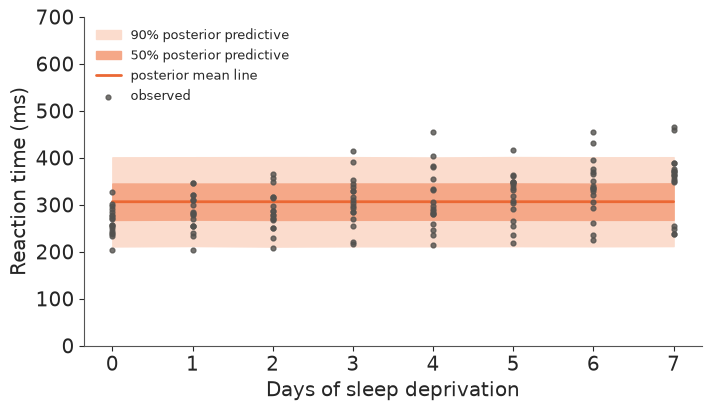

,inside_90,inside_50
Days,,
0,0.94,0.50
1,0.94,0.56
2,0.94,0.56
3,0.94,0.67
4,0.89,0.50
5,0.94,0.39
6,0.89,0.44
7,0.89,0.00


In [12]:
model.predict(idata, kind="response", inplace=True, random_seed=RANDOM_SEED)
y_post = idata["posterior_predictive"]["Reaction"].values.reshape(-1, len(sleep))
mu = (idata["posterior"]["Intercept"].values.ravel()[:, None]
      + idata["posterior"]["Days"].values.ravel()[:, None] * days)

fig, ax = plt.subplots(figsize=(7, 4))
band = {q: np.array([np.percentile(y_post[:, sleep["Days"] == d], [50 - q / 2, 50 + q / 2]) for d in days])
        for q in (90, 50)}
ax.fill_between(days, *band[90].T, color=POST_90, label="90% posterior predictive")
ax.fill_between(days, *band[50].T, color=POST_50, label="50% posterior predictive")
ax.plot(days, mu.mean(axis=0), color=POST_LINE, lw=2, label="posterior mean line")
ax.scatter(sleep["Days"], sleep["Reaction"], s=12, color=OBS, alpha=0.8, label="observed", zorder=3)
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)", ylim=(0, 700))
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.show()

coverage = pd.DataFrame({
    f"inside_{q}": (sleep["Reaction"] >= band[q][sleep["Days"], 0]) & (sleep["Reaction"] <= band[q][sleep["Days"], 1])
    for q in (90, 50)
}).groupby(sleep["Days"]).mean().round(2)
coverage  # a well-calibrated model has ~0.90 and ~0.50 on every day

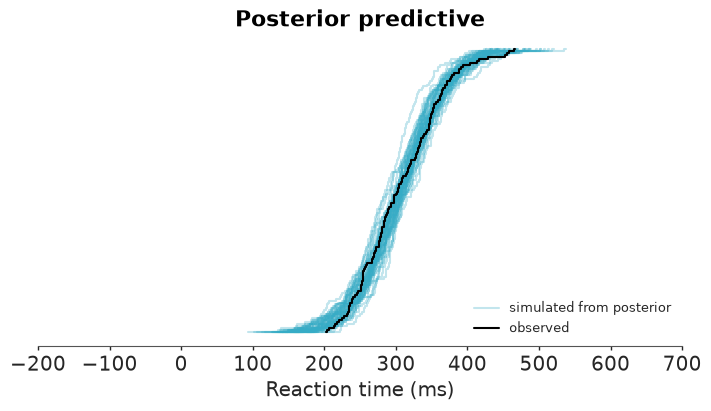

In [13]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="ecdf", figure_kwargs={"figsize": (7, 4)})

ax = plt.gcf().axes[0]
ax.set(xlabel="Reaction time (ms)", title="Posterior predictive", xlim=(-200, 700))
ax.legend([ax.lines[0], ax.lines[-1]], ["simulated from posterior", "observed"], frameon=False, fontsize=9, loc="lower right")
plt.show()

**Verdict: the flat line misses the trend, but only some checks can see it.**

- **The ECDF looks almost perfect.** It pools all 144 observations, ignoring `Days`, so a flat line at ~307 ms with σ ~57 reproduces the overall distribution well. A missing trend is invisible to this check.
- **90% coverage looks fine too:** 89–94% on every day, because the inflated σ makes the band wide enough.
- **The 50% band exposes it.** On day 7, **0%** of observations fall inside it (should be ~50%). The day-7 points lie either above the band (slowed participants) or below it (the few who didn't slow), never around the flat line. Days 5–6 are also low (39–44%), and day 3 is too high (67%).

**Lesson:** a predictive check only sees what it looks at. Checks conditioned on the predictor (per day), and at more than one interval width, catch misfits that a pooled ECDF misses.

# 2.3 Consequences of prior influence

Does the informative slope prior materially change the model’s predictions, or mainly its estimate of the deprivation slope?

# 2.4 Limits of prior tuning

Can changing the slope prior address the participant-to-participant structure visible in the data?

# 2.5 Stress-testing the slope prior

Can a strange prior **break** the fit, or does it only **distort** the answer?

These are different failures:

- **Distortion:** the posterior is pulled toward the prior, but the sampler reports no problems. This is the dangerous case, because nothing warns you.
- **Breakage:** the sampler itself struggles: divergences, $\hat R > 1.01$, low ESS.

We keep the notebook 01 priors for the intercept, N(250, 30), and $\sigma$, HalfNormal(50), and refit over a grid of slope priors $\beta \sim \mathcal{N}(m, s)$. The prior means $m$ run from −30 to +40 ms/day and the prior SDs $s$ from 0.5 (very confident) to 50 (nearly flat). Notebook 01 found about 11.6 ms/day.

The model is written directly in PyMC with $m$ and $s$ as `pm.Data`, so it is built once and each refit only swaps two numbers.

In [14]:
import logging

logging.getLogger("pymc").setLevel(logging.ERROR)  # silence per-fit sampler logs for the 49 refits

with pm.Model() as grid_model:
    slope_prior_mean = pm.Data("slope_prior_mean", 0.0)
    slope_prior_sd = pm.Data("slope_prior_sd", 1.0)

    intercept = pm.Normal("Intercept", mu=250, sigma=30)
    slope = pm.Normal("Days", mu=slope_prior_mean, sigma=slope_prior_sd)
    sigma = pm.HalfNormal("sigma", sigma=50)
    pm.Normal("Reaction", mu=intercept + slope * sleep["Days"].values, sigma=sigma,
              observed=sleep["Reaction"].values)

prior_means = [-30, -15, 0, 10, 20, 30, 40]
prior_sds = [0.5, 1, 2, 5, 10, 20, 50]

rows = []
for m in prior_means:
    for s in prior_sds:
        with grid_model:
            pm.set_data({"slope_prior_mean": m, "slope_prior_sd": s})
            fit = pm.sample(draws=1000, tune=1000, chains=4, cores=1, random_seed=RANDOM_SEED,
                            progressbar=False, compute_convergence_checks=False)
        diag = azs.summary(fit, var_names=["Intercept", "Days", "sigma"], kind="diagnostics")
        rows.append({
            "prior_mean": m, "prior_sd": s,
            "slope": fit["posterior"]["Days"].mean().item(),
            "intercept": fit["posterior"]["Intercept"].mean().item(),
            "sigma": fit["posterior"]["sigma"].mean().item(),
            "divergences": int(fit["sample_stats"]["diverging"].sum()),
            "max_rhat": diag["r_hat"].max(),
            "min_ess": diag["ess_bulk"].min(),
        })

grid = pd.DataFrame(rows)
grid["broken"] = (grid["divergences"] > 0) | (grid["max_rhat"] > 1.01) | (grid["min_ess"] < 400)
print(f"{len(grid)} fits, {grid['broken'].sum()} with sampler problems")

49 fits, 0 with sampler problems


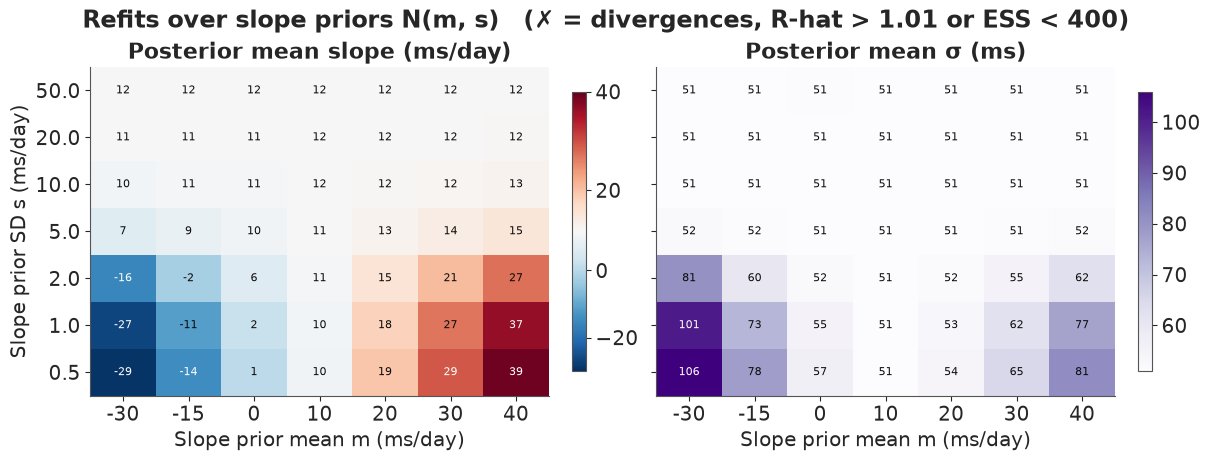

In [15]:
from matplotlib.colors import TwoSlopeNorm

# Slope: diverging, centred on what the data say with a vague prior (white = "data win").
# sigma: sequential, light = the ~51 ms of a good fit, dark = inflated noise.
data_slope = grid.loc[grid["prior_sd"] == 50, "slope"].mean()
panels = [("slope", "Posterior mean slope (ms/day)", "RdBu_r", TwoSlopeNorm(data_slope, -30, 40)),
          ("sigma", "Posterior mean σ (ms)", "Purples", None)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (col, title, cmap, norm) in zip(axes, panels):
    table = grid.pivot(index="prior_sd", columns="prior_mean", values=col)
    broken = grid.pivot(index="prior_sd", columns="prior_mean", values="broken")
    im = ax.imshow(table.values, origin="lower", cmap=cmap, norm=norm, aspect="auto")
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            r, g, b, _ = im.cmap(im.norm(table.values[i, j]))
            ink = "white" if 0.299 * r + 0.587 * g + 0.114 * b < 0.5 else "#0b0b0b"
            ax.text(j, i, f"{table.values[i, j]:.0f}" + (" ✗" if broken.values[i, j] else ""),
                    ha="center", va="center", fontsize=8, color=ink)
    ax.set(xticks=range(table.shape[1]), xticklabels=table.columns,
           yticks=range(table.shape[0]), yticklabels=table.index,
           xlabel="Slope prior mean m (ms/day)", title=title)
    fig.colorbar(im, ax=ax, shrink=0.85)
axes[0].set_ylabel("Slope prior SD s (ms/day)")
fig.suptitle("Refits over slope priors N(m, s)   (✗ = divergences, R-hat > 1.01 or ESS < 400)")
plt.show()

**Answer: across all 49 priors the fit never broke, but the answer got badly distorted.** Every fit had 0 divergences, $\hat R \le 1.01$ and ESS above 400, so no ✗ appears anywhere.

- **Wide priors (s ≥ 5): the data win.** The slope stays at 10–15 ms/day wherever the prior was centred, even at −30 or +40.
- **Narrow priors (s ≤ 2): the prior wins.** The slope follows the prior mean, from −29 ms/day for N(−30, 0.5) to +39 for N(40, 0.5). The switch happens around s ≈ 2 ms/day, which matches the slope's posterior SD in notebook 01 (1.8). A prior SD much smaller than what the data can resolve dominates.
- **σ is the tell-tale.** When the prior forces a wrong slope, the model explains the leftover slowing as noise, and σ inflates from ~51 to over 100 ms. The sampler raises no alarm, but σ and the predictive checks do.

### Priors with a strange shape

A normal prior always overlaps the data somewhere, so it can only distort. To actually break things we need priors that **rule out** what the data say:

- **A:** slope `Uniform(-5, 0)`: sleep loss can only make you faster. The truth (~11.6) is excluded.
- **B:** $\sigma \sim$ `HalfNormal(1)` ms: almost no noise allowed, when the real scatter is ~50 ms.
- **C:** intercept `Normal(1000, 1)` ms: a one-second baseline, held with near certainty.

In [16]:
base_priors = {
    "Intercept": bmb.Prior("Normal", mu=250, sigma=30),
    "Days": bmb.Prior("Normal", mu=10, sigma=10),
    "sigma": bmb.Prior("HalfNormal", sigma=50),
}
pathological = {
    "A: slope Uniform(-5, 0)": {"Days": bmb.Prior("Uniform", lower=-5, upper=0)},
    "B: sigma HalfNormal(1)": {"sigma": bmb.Prior("HalfNormal", sigma=1)},
    "C: intercept N(1000, 1)": {"Intercept": bmb.Prior("Normal", mu=1000, sigma=1)},
}

patho_fits, patho_rows = {}, {}
for label, override in pathological.items():
    m = bmb.Model("Reaction ~ Days", sleep, priors={**base_priors, **override}, center_predictors=False)
    fit = m.fit(draws=1000, chains=4, random_seed=RANDOM_SEED, progressbar=False)
    patho_fits[label] = fit
    diag = azs.summary(fit, var_names=["Intercept", "Days", "sigma"], kind="diagnostics")
    patho_rows[label] = {
        "Intercept": fit["posterior"]["Intercept"].mean().item(),
        "Days": fit["posterior"]["Days"].mean().item(),
        "sigma": fit["posterior"]["sigma"].mean().item(),
        "divergences": int(fit["sample_stats"]["diverging"].sum()),
        "max_rhat": diag["r_hat"].max(),
        "min_ess": diag["ess_bulk"].min(),
    }
pd.DataFrame(patho_rows).T.round(2)

,Intercept,Days,sigma,divergences,max_rhat,min_ess
"A: slope Uniform(-5, 0)",307.66,-0.35,57.65,0.0,1.0,2309.16
B: sigma HalfNormal(1),267.84,11.45,23.23,0.0,1.0,2165.91
"C: intercept N(1000, 1)",999.63,-80.10,391.65,0.0,1.0,3224.91


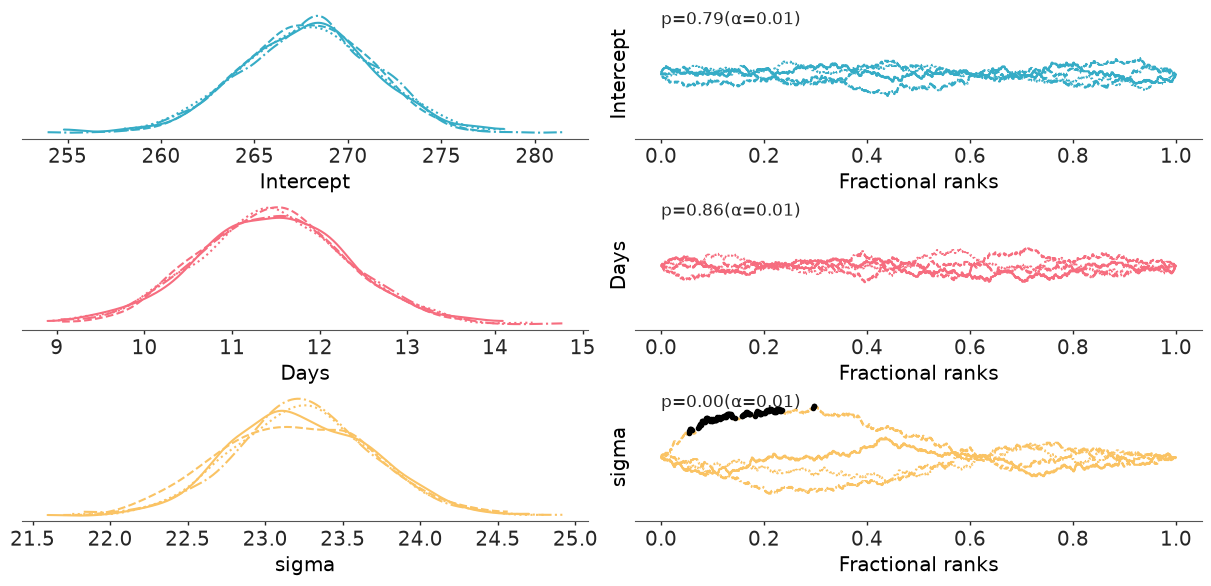

In [17]:
azp.plot_rank_dist(patho_fits["B: sigma HalfNormal(1)"], var_names=["Intercept", "Days", "sigma"]);

**Answer: even these priors don't break the sampler.** All three fits have 0 divergences, $\hat R = 1.00$ and ESS above 2000, and the rank plot for B looks clean. The damage shows up in the estimates instead:

- **A, slope `Uniform(-5, 0)`:** the slope sits at the edge it is allowed, −0.35 ms/day. The intercept rises to ~308 ms and σ to ~58 ms to compensate.
- **B, σ ~ `HalfNormal(1)`:** the data override the prior here. σ ends up at ~23 ms rather than ~1, far into the prior's tail, with the slope unchanged at 11.5. A half-normal prior has no hard wall, so enough data can push past it. σ is still pulled well below the ~51 ms it should be, so the predictive intervals would be too narrow.
- **C, intercept `Normal(1000, 1)`:** the baseline is pinned at ~1000 ms, so the slope becomes **−80 ms/day** and σ ~392 ms to reach the data at all. It is completely wrong, and the diagnostics are perfect.

**Lesson:** sampler diagnostics check the *computation*, not the *model*. A prior that contradicts the data rarely makes MCMC fail; it quietly gives a wrong answer. That is why the workflow always ends with **predictive checks**.